# Amsterdam Bike-Accident EDA (2021–2023)

**Goals:**
1. Explore how _light_, _road_, and _weather_ conditions relate to accident counts  
2. Find the streets with the most accidents  
3. Find which road surfaces see the most accidents  
4. Identify the top “nature of accident” causes  

---

## 1. Setup & Load Data


In [1]:
# Standard library imports
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path to import our custom module
sys.path.append('..')

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster

# Machine learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
import hdbscan

# Import functions
from function_06 import load_csv

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

import geopandas as gpd
from geodatasets import get_path
from shapely.geometry import Point

import re
import pyproj

print("All libraries imported successfully!")
print(f"Working directory: {os.getcwd()}")

All libraries imported successfully!
Working directory: /Users/volkan.coskun/esra/data/Week_9/Prediction_Bike_Accident_New/notebook


In [2]:
file_path= ('../data/cleaned/gdf_ams_21_23.csv')
gdf_ams = load_csv(file_path)

In [3]:
gdf_ams.head()

,Unnamed: 0,accident_id,accident_year,outcome,num_parties,party1_type,party2_type,accident_nature,road_situation,built_up_area,...,road_surface,road_condition,light_condition,weather_condition,street_name,municipality,shape,geometry,longitude,latitude
0,58,20210077485,2021,Uitsluitend materiele schade,2,personenauto,bromfiets,Flank,"Kruispunt, 4 takken",Binnen,...,Unknown,Nat,Duisternis,Droog,Middenweg,amsterdam,POINT (124415.5298999995 484676.3922000006),POINT (4.938331880430102 52.3491439360283),4.938332,52.349144
1,91,20210081692,2021,Uitsluitend materiele schade,2,personenauto,e-bike,Frontaal,"Kruispunt, 3 takken",Binnen,...,Overig asfalt,Droog,Daglicht,Droog,Overschiestraat,amsterdam,POINT (117678.65309999883 484278.08260000125),POINT (4.83950635628552 52.34514797053482),4.839506,52.345148
2,106,20210081708,2021,Uitsluitend materiele schade,2,snorfiets,fiets,Frontaal,Rechte weg,Binnen,...,Overig asfalt,Droog,Daglicht,Droog,Rozenburglaan,amsterdam,POINT (124437.1950000003 483597.2190000005),POINT (4.938747822317208 52.33944619086022),4.938748,52.339446
3,154,20210080056,2021,Uitsluitend materiele schade,2,e-bike,landbouwvoertuig,Flank,"Kruispunt, 4 takken",Binnen,...,Overig asfalt,Droog,Daglicht,Droog,Th. K. van Lohuizenlaan,amsterdam,POINT (124961 486566),POINT (4.946168489078478 52.366156634505806),4.946168,52.366157
4,155,20210080070,2021,Uitsluitend materiele schade,2,personenauto,fiets,Flank,"Kruispunt, 4 takken",Binnen,...,Overig asfalt,Droog,Daglicht,Droog,Spuistraat,amsterdam,POINT (121107.48209999874 487274.5234000012),POINT (4.889521223504305 52.37230007491118),4.889521,52.372300


In [4]:
# 1) Center the map on Amsterdam
amsterdam_center = [52.3676, 4.9041]
m = folium.Map(location=amsterdam_center, zoom_start=12, tiles="CartoDB positron")

# 2) Add a MarkerCluster layer
marker_cluster = MarkerCluster(name="Bike Accidents").add_to(m)

# 3) Add each crash as a marker
for i, row in gdf_ams.iterrows():
    folium.Marker(
        location=[row.latitude, row.longitude],
        popup=(
            f"ID: {row.accident_id}<br>"
            f"Year: {row.accident_year}<br>"
            f"Outcome: {row.outcome}<br>"
            f"Light: {row.light_condition}<br>"
            f"Weather: {row.weather_condition}"
        )
    ).add_to(marker_cluster)

In [36]:
# 5. Add a heatmap overlay
heat_data = gdf_ams[['latitude','longitude']].values.tolist()
HeatMap(heat_data, radius=8, blur=12, name="Heatmap").add_to(m)

# 6. Layer control & display/save
folium.LayerControl().add_to(m)

# If in a notebook, just display 'm' and it will render.
# If in a script, uncomment the next line to save to HTML:
m.save("../presentation/amsterdam_bike_accidents_cluster.html")

In [5]:
m

### 2-Overal Accident trends by year

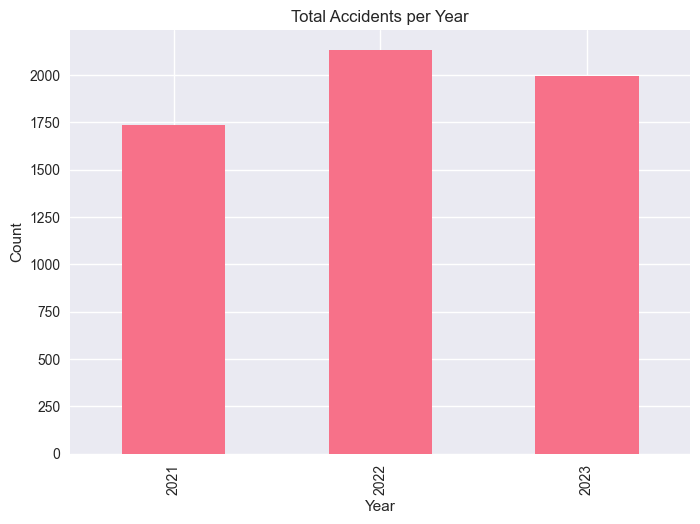

<Figure size 800x550 with 0 Axes>

In [5]:
year_counts = gdf_ams["accident_year"].value_counts().sort_index()
year_counts.plot.bar()
plt.title("Total Accidents per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()
plt.savefig('../docs/year_counts.png')

## Relation with Conditions
3.1 Light Conditions

3.2 Street Lighting

3.3 Weather Conditions

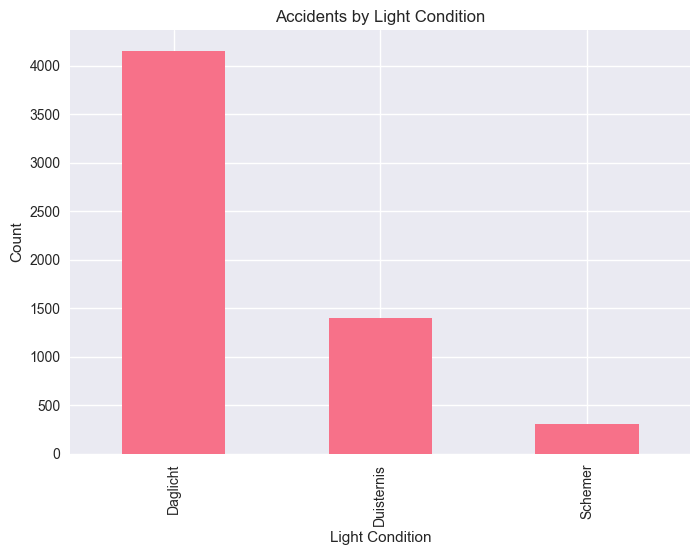

<Figure size 800x550 with 0 Axes>

In [ ]:
#Lighting condition effect 
lc = gdf_ams["light_condition"].value_counts(ascending=False)
lc.plot.bar()
plt.title("Accidents by Light Condition")
plt.xlabel("Light Condition")
plt.ylabel("Count")
plt.show()
plt.savefig('../docs/accident_by_ligt_condition.png')

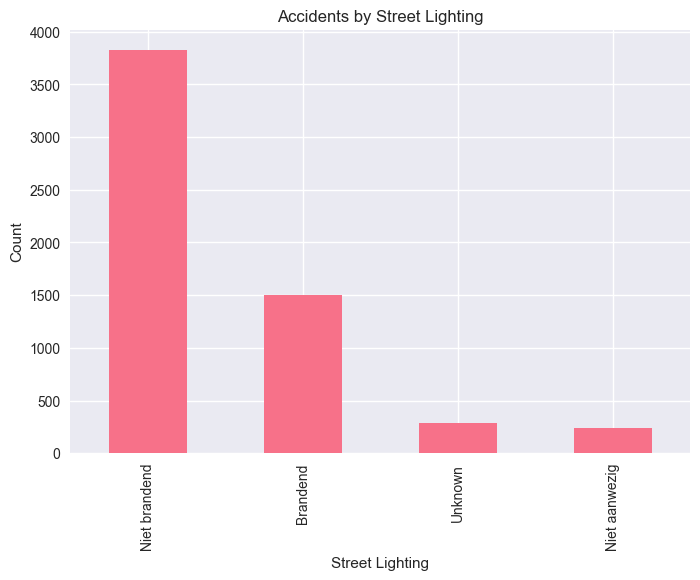

<Figure size 800x550 with 0 Axes>

In [7]:
#Street lighting 
sl = gdf_ams["street_lighting"].value_counts(ascending=False)
sl.plot.bar()
plt.title("Accidents by Street Lighting")
plt.xlabel("Street Lighting")
plt.ylabel("Count")
plt.show()
plt.savefig("../docs/accident_by_street_light.png")


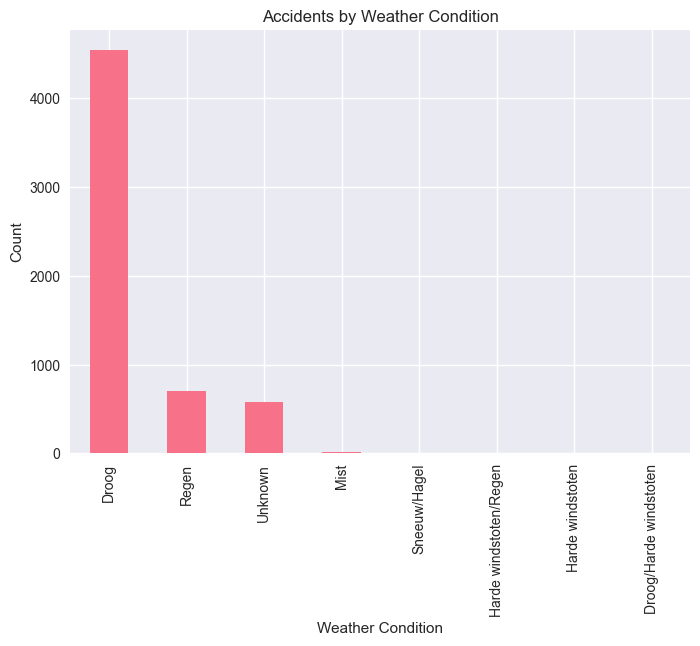

<Figure size 800x550 with 0 Axes>

In [8]:
#weather conditions
wc = gdf_ams["weather_condition"].value_counts()
wc.plot.bar()
plt.title("Accidents by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Count")
plt.show()
plt.savefig("../docs/weather_conditions.png")

### 4. Top Streets & Surfaces
- 4.1.  Streets with Most Accidents
- 4.2.  Road Surface Types
### 5. Accident Nature (Cause)
### 6. Multi-factor Pivot Tables 


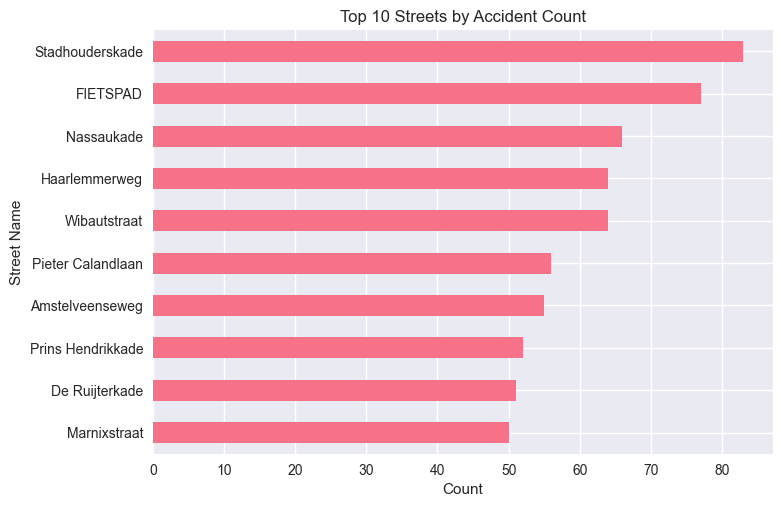

<Figure size 800x550 with 0 Axes>

In [9]:
#Street with most accident happened
top_streets = gdf_ams["street_name"].value_counts().head(10)
top_streets.plot.barh()
plt.title("Top 10 Streets by Accident Count")
plt.xlabel("Count")
plt.ylabel("Street Name")
plt.gca().invert_yaxis()
plt.show()
plt.savefig("../docs/top_streets_count.png")

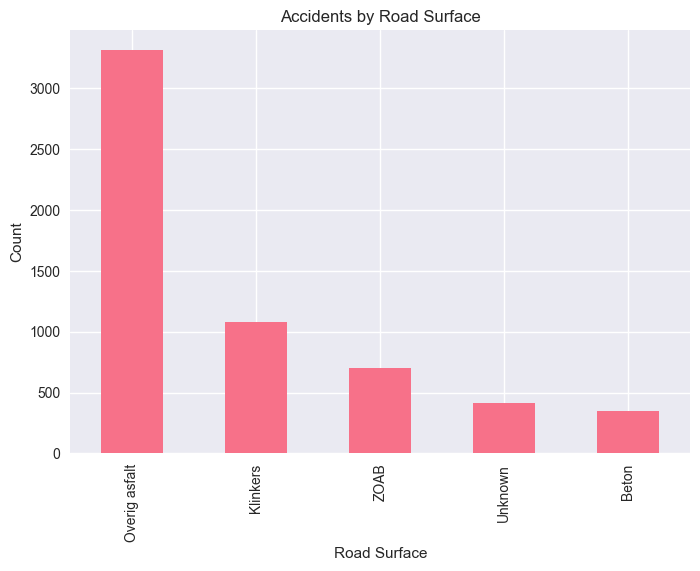

<Figure size 800x550 with 0 Axes>

In [10]:
#Road surface
rs = gdf_ams["road_surface"].value_counts()
rs.plot.bar()
plt.title("Accidents by Road Surface")
plt.xlabel("Road Surface")
plt.ylabel("Count")
plt.show()
plt.savefig("../docs/road_suface.png")

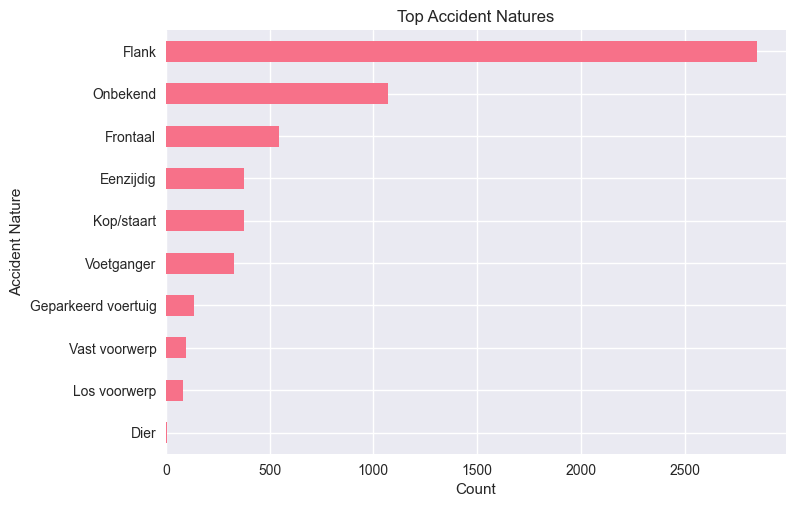

In [77]:
#Accident cause
an = gdf_ams["accident_nature"].value_counts().head(10)
an.plot.barh()
plt.title("Top Accident Natures")
plt.xlabel("Count")
plt.ylabel("Accident Nature")
plt.gca().invert_yaxis()
plt.show()


In [105]:
#Multi-factor Pivot Tables 
pivot = (gdf_ams.pivot_table(
        index="light_condition",
        columns="weather_condition",
        aggfunc="size",
        fill_value=0
    )
    # sort rows and columns in descending alphabetical (or change axis=0↔1 as needed)
    .sort_index(axis=0, ascending=True)
    .sort_index(axis=1, ascending=True)
)

# Display the pivot
display(pivot)


weather_condition,Droog,Droog/Harde windstoten,Harde windstoten,Harde windstoten/Regen,Mist,Regen,Sneeuw/Hagel,Unknown
light_condition,,,,,,,,
Daglicht,3315,2,3,5,5,421,3,403
Duisternis,1009,0,0,0,8,237,4,140
Schemer,216,0,1,0,2,47,0,37


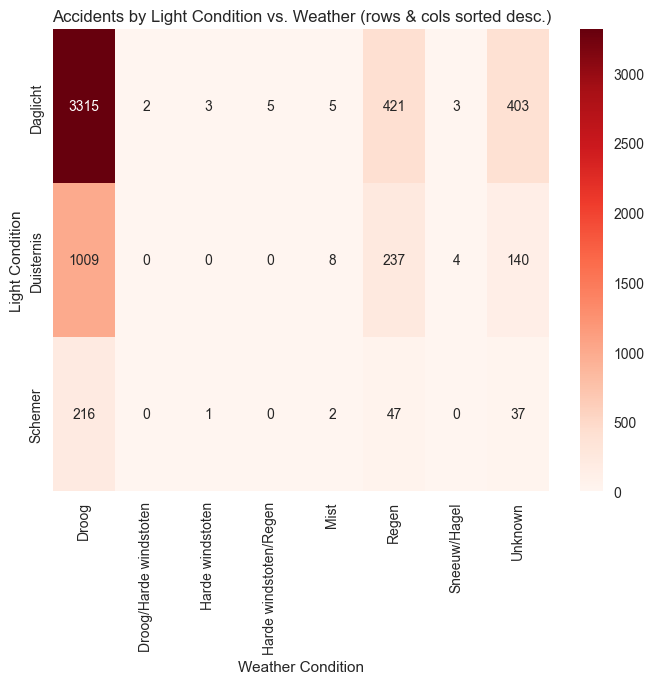

In [ ]:
#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds")
plt.title("Accidents by Light Condition vs. Weather (rows & cols sorted desc.)")
plt.xlabel("Weather Condition")
plt.ylabel("Light Condition")
plt.show()
plt.savefig("../docs/weather_light_conditions_matrix.png")

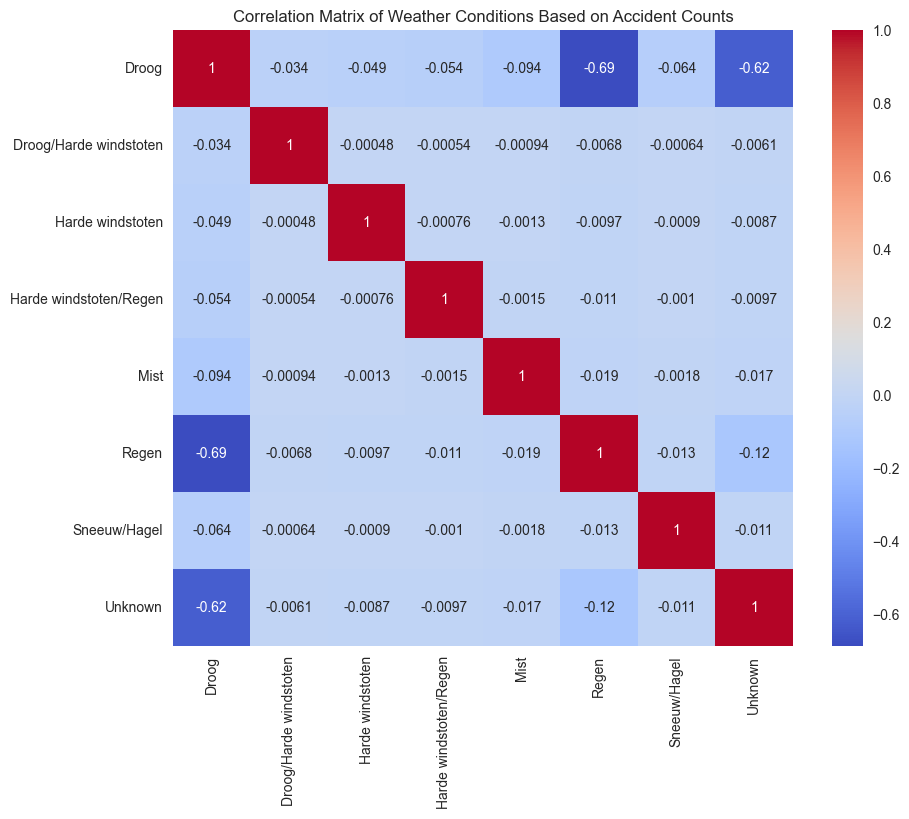

<Figure size 800x550 with 0 Axes>

In [8]:
 #1. One-hot encode weather conditions
weather_encoded = pd.get_dummies(gdf_ams['weather_condition'])

# 2. (Optional) If you want to group by another variable (e.g., year, location), do it here
# For overall correlation, just use the one-hot encoded DataFrame

# 3. Compute the correlation matrix
weather_corr_matrix = weather_encoded.corr()

# 4. Display the correlation matrix


plt.figure(figsize=(10, 8))
sns.heatmap(weather_corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Weather Conditions Based on Accident Counts')
plt.show()
plt.savefig('../docs/weather_corr_matrix.png')